# Moving Average filter



`torch_dtype` is deprecated! Use `dtype` instead!


Segment 1/251 — RMSE: 27.91 | MAPE: 1.38% | R²: 0.5713 | Dir Acc: 46.7%
Segment 2/251 — RMSE: 24.22 | MAPE: 1.10% | R²: 0.1704 | Dir Acc: 60.0%
Segment 3/251 — RMSE: 35.56 | MAPE: 1.47% | R²: 0.0043 | Dir Acc: 40.0%
Segment 4/251 — RMSE: 46.35 | MAPE: 2.54% | R²: 0.3822 | Dir Acc: 36.7%
Segment 5/251 — RMSE: 34.22 | MAPE: 1.62% | R²: 0.5134 | Dir Acc: 46.7%
Segment 6/251 — RMSE: 60.88 | MAPE: 2.80% | R²: 0.8911 | Dir Acc: 50.0%
Segment 7/251 — RMSE: 61.98 | MAPE: 2.75% | R²: 0.8131 | Dir Acc: 36.7%
Segment 8/251 — RMSE: 22.71 | MAPE: 0.87% | R²: 0.1130 | Dir Acc: 56.7%
Segment 9/251 — RMSE: 54.55 | MAPE: 2.54% | R²: 0.3336 | Dir Acc: 36.7%
Segment 10/251 — RMSE: 103.87 | MAPE: 5.35% | R²: 0.5653 | Dir Acc: 43.3%
Segment 11/251 — RMSE: 46.16 | MAPE: 2.13% | R²: 0.2283 | Dir Acc: 40.0%
Segment 12/251 — RMSE: 99.61 | MAPE: 4.49% | R²: 0.0075 | Dir Acc: 50.0%
Segment 13/251 — RMSE: 29.09 | MAPE: 1.24% | R²: 0.1217 | Dir Acc: 43.3%
Segment 14/251 — RMSE: 108.62 | MAPE: 3.98% | R²: 0.0913 | 

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_42017/2501736712.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


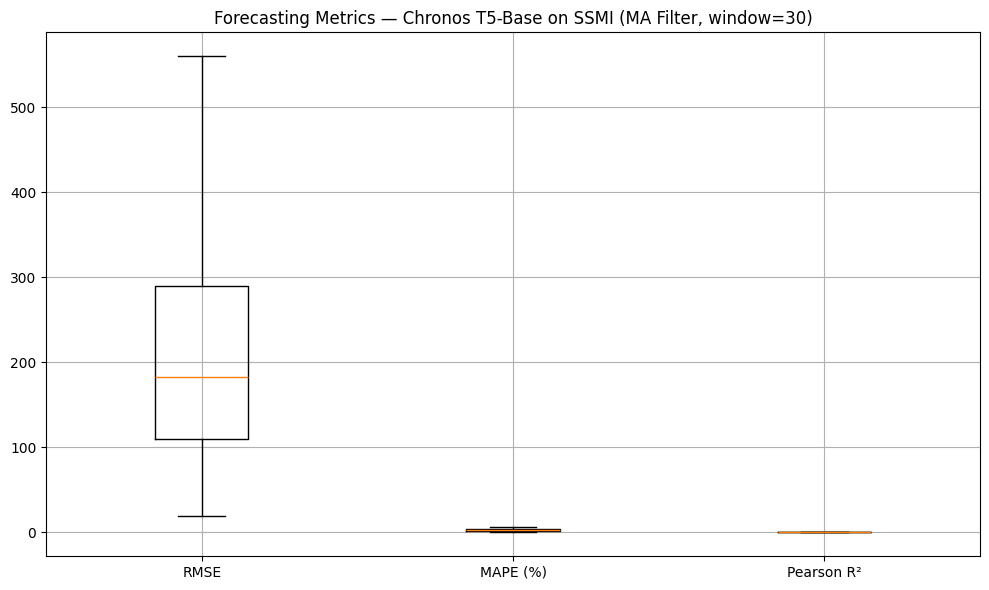

In [1]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='ChronosBase_SSMI_Filtered_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def moving_average_decompose_context(y_context, window=20):
    """Causal decomposition on context only to avoid look-ahead leakage."""
    low = pd.Series(y_context).rolling(window=window, min_periods=1).mean().to_numpy()
    high = y_context - low
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Filter config
        # ========================
        filter_window = 30  # 30-day moving average (approx. 1 trading month)
        logging.info(f"Using causal moving average decomposition with window={filter_window}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:end_context + forecast_horizon]

            # Decompose only the context to avoid peeking into forecast horizon
            context_low_np, context_high_np = moving_average_decompose_context(
                y_context,
                window=filter_window
            )
            context_low = torch.tensor(context_low_np.copy(), dtype=torch.float32)
            context_high = torch.tensor(context_high_np.copy(), dtype=torch.float32)

            # Forecast low-frequency (trend)
            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Forecast high-frequency (residual)
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Recombine predictions
            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            prev_values = np.concatenate([[y[end_context - 1]], y_true[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])
            actual_direction = np.sign(y_true - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape       = mean_absolute_percentage_error(y_true, combined_pred) * 100
            pearson_r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_Filtered_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            filter_window=filter_window,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_Filtered_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Filtered) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (MA Filter, window={filter_window})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Filtered_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_Filtered_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()


# Hodrick–Prescott filter

Segment 1/251 — RMSE: 24.37 | MAPE: 1.28% | R²: 0.3276 | Dir Acc: 53.3%
Segment 2/251 — RMSE: 33.68 | MAPE: 1.82% | R²: 0.5677 | Dir Acc: 66.7%
Segment 3/251 — RMSE: 31.37 | MAPE: 0.90% | R²: 0.0051 | Dir Acc: 66.7%
Segment 4/251 — RMSE: 40.10 | MAPE: 2.12% | R²: 0.5318 | Dir Acc: 50.0%
Segment 5/251 — RMSE: 45.25 | MAPE: 2.18% | R²: 0.2182 | Dir Acc: 50.0%
Segment 6/251 — RMSE: 92.78 | MAPE: 4.20% | R²: 0.5504 | Dir Acc: 56.7%
Segment 7/251 — RMSE: 38.95 | MAPE: 1.80% | R²: 0.7619 | Dir Acc: 66.7%
Segment 8/251 — RMSE: 60.24 | MAPE: 3.07% | R²: 0.6693 | Dir Acc: 60.0%
Segment 9/251 — RMSE: 32.79 | MAPE: 1.39% | R²: 0.3373 | Dir Acc: 66.7%
Segment 10/251 — RMSE: 113.47 | MAPE: 5.71% | R²: 0.5539 | Dir Acc: 36.7%
Segment 11/251 — RMSE: 52.35 | MAPE: 2.65% | R²: 0.4627 | Dir Acc: 50.0%
Segment 12/251 — RMSE: 154.48 | MAPE: 7.33% | R²: 0.4582 | Dir Acc: 33.3%
Segment 13/251 — RMSE: 31.36 | MAPE: 1.34% | R²: 0.2194 | Dir Acc: 56.7%
Segment 14/251 — RMSE: 57.98 | MAPE: 2.31% | R²: 0.9119 | 

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_42017/3177015039.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


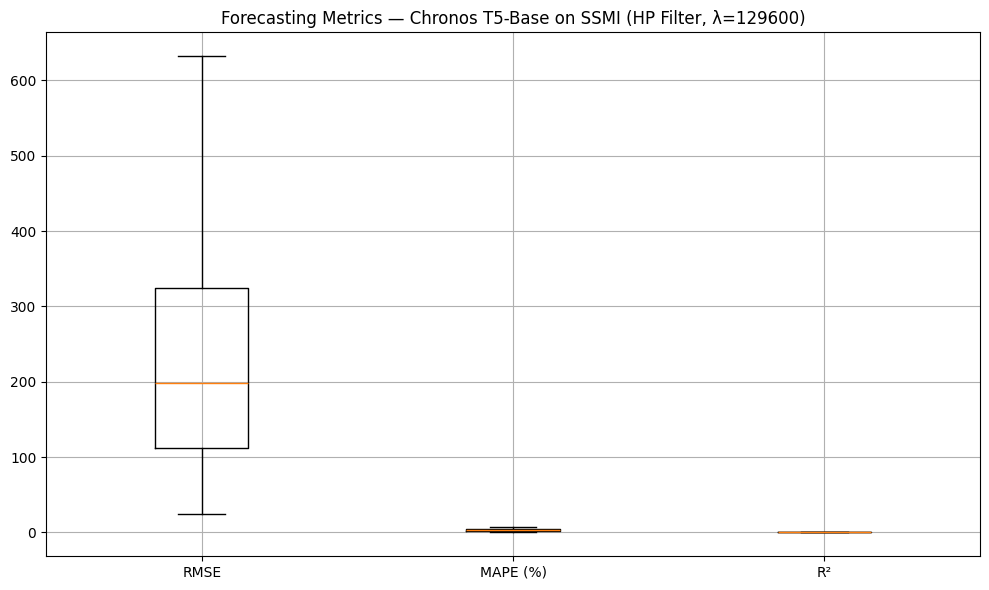

In [2]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.filters.hp_filter import hpfilter

logging.basicConfig(
    filename='ChronosBase_SSMI_HP_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def hp_decompose_context(y_context, lamb):
    """Apply HP decomposition on context only to avoid look-ahead leakage."""
    cycle, trend = hpfilter(y_context, lamb=lamb)
    return np.asarray(trend, dtype=float), np.asarray(cycle, dtype=float)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) HP config
        # ========================
        lamb = 129600
        logging.info(f"Using context-only HP decomposition with lambda={lamb}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200 
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        r2_list          = []
        directional_hits = []  # 1 if direction correct (up or down), 0 otherwise

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:end_context + forecast_horizon]

            context_low_np, context_high_np = hp_decompose_context(y_context, lamb=lamb)
            context_low = torch.tensor(context_low_np.copy(), dtype=torch.float32)
            context_high = torch.tensor(context_high_np.copy(), dtype=torch.float32)

            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # ========================
            # Directional accuracy
            # (correct up AND correct down)
            # ========================
            prev_day_price = y[end_context - 1]

            # Previous day anchor for actual and forecast
            actual_prev = np.concatenate([[prev_day_price], y_true[:-1]])
            pred_prev   = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(y_true - actual_prev)  # +1 up, -1 down, 0 flat
            pred_direction   = np.sign(combined_pred  - pred_prev)   # +1 up, -1 down, 0 flat

            # 1 point if direction matches (both up or both down)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            # Standard metrics
            rmse = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape = mean_absolute_percentage_error(y_true, combined_pred) * 100
            r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            r2_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R²={r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_HP_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            r2=np.array(r2_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            lamb=lamb,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_HP_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (HP Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median R²:            {np.median(r2_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":     rmse_list,
            "MAPE (%)": mape_list,
            "R²":       r2_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (HP Filter, λ={lamb})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_HP_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_HP_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                r2=np.array(r2_list) if 'r2_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()


# 5 Hz Cutoff (butter worth filter)

Segment 1/251 — RMSE: 131.86 | MAPE: 6.04% | R²: 0.2372 | Dir Acc: 43.3%
Segment 2/251 — RMSE: 95.39 | MAPE: 4.54% | R²: 0.6750 | Dir Acc: 30.0%
Segment 3/251 — RMSE: 43.57 | MAPE: 1.77% | R²: 0.0230 | Dir Acc: 43.3%
Segment 4/251 — RMSE: 75.50 | MAPE: 3.99% | R²: 0.3989 | Dir Acc: 33.3%
Segment 5/251 — RMSE: 38.42 | MAPE: 1.91% | R²: 0.3547 | Dir Acc: 43.3%
Segment 6/251 — RMSE: 169.04 | MAPE: 8.09% | R²: 0.7116 | Dir Acc: 36.7%
Segment 7/251 — RMSE: 158.46 | MAPE: 5.59% | R²: 0.4594 | Dir Acc: 43.3%
Segment 8/251 — RMSE: 36.29 | MAPE: 1.38% | R²: 0.1208 | Dir Acc: 43.3%
Segment 9/251 — RMSE: 153.28 | MAPE: 5.65% | R²: 0.0065 | Dir Acc: 43.3%
Segment 10/251 — RMSE: 94.94 | MAPE: 3.77% | R²: 0.5618 | Dir Acc: 46.7%
Segment 11/251 — RMSE: 51.77 | MAPE: 1.92% | R²: 0.3936 | Dir Acc: 53.3%
Segment 12/251 — RMSE: 59.88 | MAPE: 2.56% | R²: 0.6375 | Dir Acc: 53.3%
Segment 13/251 — RMSE: 66.12 | MAPE: 2.91% | R²: 0.2169 | Dir Acc: 53.3%
Segment 14/251 — RMSE: 117.67 | MAPE: 4.59% | R²: 0.0004

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_42017/3983869455.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


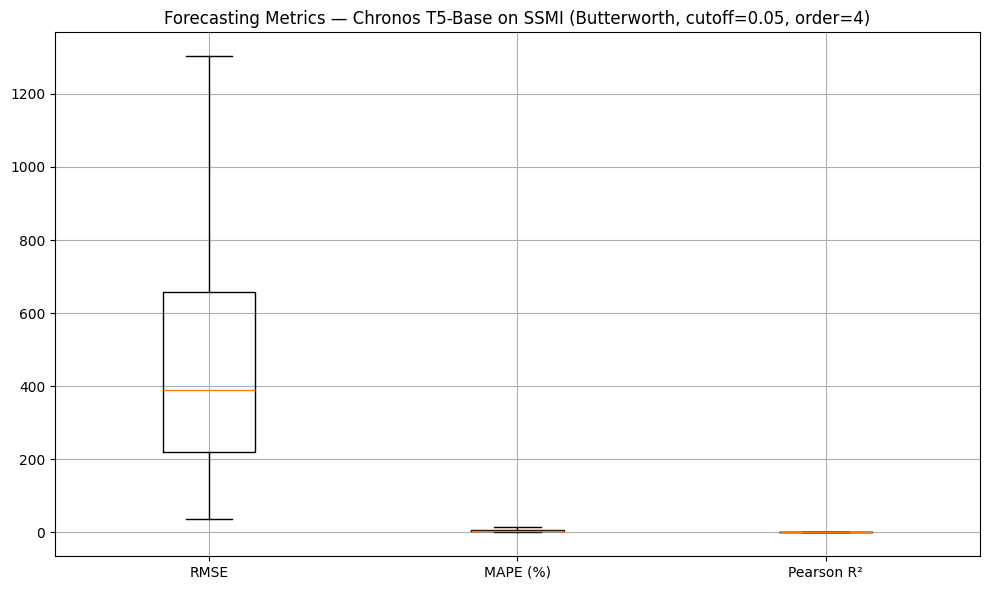

In [3]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr
from scipy.signal import butter, lfilter

logging.basicConfig(
    filename='ChronosBase_SSMI_Butterworth_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def butterworth_decompose_context(y_context, cutoff=0.05, order=4):
    """Causal Butterworth decomposition on context only to avoid look-ahead leakage."""
    b, a = butter(order, cutoff, btype='low')
    low = lfilter(b, a, y_context)
    high = y_context - low
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv(
            "/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv",
            parse_dates=["Date"]
        )
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Filter config
        # ========================
        cutoff = 0.05
        filter_order = 4
        logging.info(f"Using context-only causal Butterworth decomposition with cutoff={cutoff}, order={filter_order}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window

            if end_context + forecast_horizon > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:end_context + forecast_horizon]

            # Decompose only the context to avoid peeking into forecast horizon
            context_low_np, context_high_np = butterworth_decompose_context(
                y_context,
                cutoff=cutoff,
                order=filter_order
            )
            context_low = torch.tensor(context_low_np.copy(), dtype=torch.float32)
            context_high = torch.tensor(context_high_np.copy(), dtype=torch.float32)

            # Forecast low component
            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Forecast high component
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Recombine predictions
            median_low    = np.median(forecast_low[0].numpy(), axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # Directional accuracy
            prev_values = np.concatenate([[y[end_context - 1]], y_true[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])

            actual_direction = np.sign(y_true - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)

            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape       = mean_absolute_percentage_error(y_true, combined_pred) * 100
            pearson_r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(
                f"Segment {segment+1}/{num_segments}: "
                f"RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%"
            )
            print(
                f"Segment {segment+1}/{num_segments} — "
                f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%"
            )

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed(
            "ChronosBase_SSMI_Butterworth_Metrics.npz",
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            pearson_coefficients=np.array(pearson_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            cutoff=cutoff,
            filter_order=filter_order,
            num_segments=num_segments
        )
        logging.info("Results saved to ChronosBase_SSMI_Butterworth_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days > 0 else 0.0

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Butterworth Filter) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(
            f"Forecasting Metrics — Chronos T5-Base on SSMI "
            f"(Butterworth, cutoff={cutoff}, order={filter_order})"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Butterworth_Metrics.log for details.")
        try:
            np.savez_compressed(
                "partial_ChronosBase_SSMI_Butterworth_Metrics.npz",
                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None
            )
        except Exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()


# Kalman Filter

Segment 1/251 — RMSE: 20.35 | MAPE: 0.99% | R²: 0.6107 | Dir Acc: 50.0%
Segment 2/251 — RMSE: 16.14 | MAPE: 0.80% | R²: 0.5719 | Dir Acc: 60.0%
Segment 3/251 — RMSE: 38.90 | MAPE: 1.36% | R²: 0.0323 | Dir Acc: 40.0%
Segment 4/251 — RMSE: 30.71 | MAPE: 1.72% | R²: 0.6272 | Dir Acc: 43.3%
Segment 5/251 — RMSE: 37.05 | MAPE: 1.83% | R²: 0.3543 | Dir Acc: 63.3%
Segment 6/251 — RMSE: 113.33 | MAPE: 5.34% | R²: 0.2961 | Dir Acc: 40.0%
Segment 7/251 — RMSE: 28.92 | MAPE: 1.16% | R²: 0.3371 | Dir Acc: 56.7%
Segment 8/251 — RMSE: 17.78 | MAPE: 0.75% | R²: 0.1402 | Dir Acc: 50.0%
Segment 9/251 — RMSE: 39.58 | MAPE: 1.73% | R²: 0.3428 | Dir Acc: 43.3%
Segment 10/251 — RMSE: 84.26 | MAPE: 4.18% | R²: 0.4142 | Dir Acc: 50.0%
Segment 11/251 — RMSE: 45.78 | MAPE: 2.00% | R²: 0.0017 | Dir Acc: 50.0%
Segment 12/251 — RMSE: 107.24 | MAPE: 5.07% | R²: 0.1557 | Dir Acc: 40.0%
Segment 13/251 — RMSE: 231.10 | MAPE: 3.44% | R²: 0.0176 | Dir Acc: 60.0%
Segment 14/251 — RMSE: 110.57 | MAPE: 4.40% | R²: 0.5131 

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_42017/885965835.py:196: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


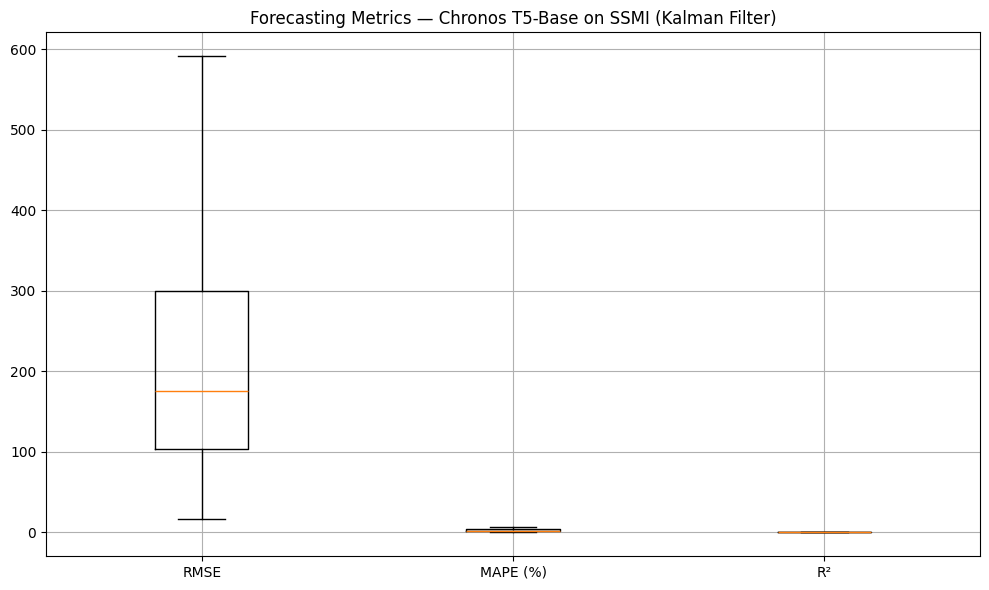

In [4]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.statespace.structural import UnobservedComponents
from scipy.stats import pearsonr


logging.basicConfig(
    filename='ChronosBase_SSMI_Kalman_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def kalman_decompose_train_only(y_context, forecast_horizon):
    """
    Fit a local linear trend state-space model on context only.
    Use filtered states (not smoothed) to avoid look-ahead leakage.
    Forecast the low-frequency trend forward, and model the high-frequency
    component as the filtered residual with zero-mean future expectation.
    """
    model = UnobservedComponents(
        y_context,
        level='local linear trend'
    )
    result = model.fit(disp=False)

    # Use filtered state estimates only: past information up to each time t
    filtered_level = result.level.filtered
    low_context = np.asarray(filtered_level, dtype=float)
    high_context = np.asarray(y_context - low_context, dtype=float)

    # Forecast only the low-frequency component
    low_forecast = np.asarray(result.forecast(steps=forecast_horizon), dtype=float)

    # Zero-mean assumption for future residual/high-frequency component
    high_forecast = np.zeros(forecast_horizon, dtype=float)

    return low_context, high_context, low_forecast, high_forecast, result

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv(
            "/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv",
            parse_dates=["Date"]
        )
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window = 120
        forecast_horizon = 30
        step_size = 30
        num_segments = (total_samples - context_window - forecast_horizon) // step_size + 1
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 4) Rolling evaluation
        # ========================
        rmse_list = []
        mape_list = []
        r2_list = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context = start_context + context_window
            forecast_end = end_context + forecast_horizon

            if forecast_end > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:forecast_end]

            # Kalman decomposition fitted only on context
            low_context, high_context, low_forecast_kf, high_forecast_kf, _ = kalman_decompose_train_only(
                y_context,
                forecast_horizon
            )

            # Chronos forecasts the two components separately
            context_low_t = torch.tensor(low_context.copy(), dtype=torch.float32)
            context_high_t = torch.tensor(high_context.copy(), dtype=torch.float32)

            forecast_low = pipeline.predict(
                context_low_t,
                prediction_length=forecast_horizon,
                num_samples=20,
            )
            forecast_high = pipeline.predict(
                context_high_t,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Combine Chronos samples coherently
            combined_samples = forecast_low[0].numpy() + forecast_high[0].numpy()
            combined_pred = combined_samples.mean(axis=0)

            # Optional hybrid:
            # combine Chronos residual forecast with Kalman trend forecast
            # uncomment next line if you want that instead
            # combined_pred = low_forecast_kf + forecast_high[0].numpy().mean(axis=0)

            prev_day_price = y[end_context - 1]
            actual_prev = np.concatenate([[prev_day_price], y_true[:-1]])
            pred_prev = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(y_true - actual_prev)
            pred_direction = np.sign(combined_pred - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            rmse = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape = mean_absolute_percentage_error(y_true, combined_pred) * 100
            r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            r2_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(
                f"Segment {segment+1}/{num_segments}: "
                f"RMSE={rmse:.4f}, MAPE={mape:.4f}%, "
                f"R2={r2:.4f}, DirAcc={segment_dir_acc:.1f}%"
            )
            print(
                f"Segment {segment+1}/{num_segments} — "
                f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | "
                f"R²: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%"
            )

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed(
            "ChronosBase_SSMI_Kalman_Metrics.npz",
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            r2=np.array(r2_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            step_size=step_size,
            num_segments=len(rmse_list)
        )
        logging.info("Results saved to ChronosBase_SSMI_Kalman_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        total_days = len(directional_hits)
        total_hits = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days > 0 else np.nan

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Kalman Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median R²:            {np.median(r2_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE": rmse_list,
            "MAPE (%)": mape_list,
            "R²": r2_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics — Chronos T5-Base on SSMI (Kalman Filter)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Kalman_Metrics.log for details.")
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()
